
# Patient visualization workbench for `open_hand` vs `all_other_gestures`

Этот ноутбук нужен для **ручного просмотра и отбора картинок** по одному пациенту (например, `s11`).

Он делает следующее:

1. загружает `study_definition_open_vs_all`;
2. выбирает пациента и его сессии;
3. загружает соответствующие EDF-файлы;
4. выполняет препроцессинг, согласованный с текущим пайплайном;
5. строит визуализации по **всем retained channels**:
   - средние сырые/предобработанные сигналы по классам;
   - разность между классами;
   - TFR по классам и их разность;
6. сохраняет изображения в понятную структуру подпапок.

Ноутбук ориентирован на задачу:

- **positive class**: `open_hand`
- **negative class**: `all_other_gestures`

Если потом появятся новые запуски и новая постановка, этот ноутбук можно будет адаптировать.



## 0. Параметры

В этом блоке меняются основные настройки:

- `PATIENT_ID` — пациент, которого смотришь;
- `STUDY_DEF_PATH` — путь к папке `study_definition_open_vs_all` **или** к zip-архиву;
- `DATA_ROOT` — корень датасета с EDF;
- `OUTPUT_ROOT` — куда сохранять картинки;
- `SESSIONS_TO_USE` — `None` для всех сессий пациента или список конкретных сессий;
- `PLOT_TMIN_ROBOT`, `PLOT_TMAX_ROBOT` — окно визуализации относительно **начала движения робота**;
- `ROBOT_DELAY_S` — задержка между LSL-меткой и началом движения робота.


In [51]:

from pathlib import Path

# ======== WHAT TO LOOK AT ========
PATIENT_ID = 's11'
SESSIONS_TO_USE = None  # None -> all sessions of the patient; or e.g. ['2025-09-02_s11/session_1']

# ======== INPUTS ========
STUDY_DEF_PATH = Path('/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/study_definition_open_vs_all')  # folder or .zip
DATA_ROOT = Path('/trinity/home/t.samsonov/notebooks/Pirogov/PirogovDATA')

# ======== OUTPUTS ========
OUTPUT_ROOT = Path('/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs') / PATIENT_ID

# ======== TIMING ========
ROBOT_DELAY_S = 0.100  # confirmed approximation used in the current project
PLOT_TMIN_ROBOT = -1.0
PLOT_TMAX_ROBOT = 2.0

# Internally, epochs are cut relative to the LSL marker.
# If robot onset = marker + 0.1 s, then [-1, +2] relative to robot
# becomes [-1.1, +1.9] relative to the marker.
EPOCH_TMIN_MARKER = PLOT_TMIN_ROBOT - ROBOT_DELAY_S
EPOCH_TMAX_MARKER = PLOT_TMAX_ROBOT - ROBOT_DELAY_S

# ======== PREPROCESSING ========
NOTCH_FREQS = [50, 100, 150]
L_FREQ = 0.1
H_FREQ = 120.0

# ======== TFR ========
TFR_FMIN = 0.1
TFR_FMAX = 120.0
TFR_N_FREQS = 100
TFR_DECIM = 2
TFR_BASELINE = (-1.0, -0.2)  # relative to robot onset, used only for TFR normalization
TFR_BASELINE_MODE = 'logratio'  # 'logratio', 'percent', 'zscore', or None

# ======== SAVING / PLOTTING ========
FIG_DPI = 160
SAVE_PNG = True
SAVE_SVG = False
SHOW_INLINE_PREVIEW = True
MAX_CHANNELS_PER_FIGURE = 8  # used for channel-grid TFR figures


## 1. Импорты и служебные функции

In [52]:

import io
import json
import math
import zipfile
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from IPython.display import display, Markdown

plt.rcParams['figure.dpi'] = FIG_DPI
plt.rcParams['savefig.dpi'] = FIG_DPI
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def split_retained_channels(s: str):
    if pd.isna(s) or not str(s).strip():
        return []
    return [x for x in str(s).split('|') if x]


def load_table(study_def_path: Path, relative_path: str) -> pd.DataFrame:
    if study_def_path.is_dir():
        return pd.read_csv(study_def_path / relative_path)
    if study_def_path.suffix.lower() == '.zip':
        with zipfile.ZipFile(study_def_path, 'r') as zf:
            target = None
            for name in zf.namelist():
                if name.endswith('/' + relative_path) or name == relative_path:
                    target = name
                    break
            if target is None:
                raise FileNotFoundError(f'Cannot find {relative_path} inside {study_def_path}')
            with zf.open(target) as f:
                return pd.read_csv(f)
    raise ValueError(f'Unsupported STUDY_DEF_PATH: {study_def_path}')


def load_json(study_def_path: Path, relative_path: str):
    if study_def_path.is_dir():
        with open(study_def_path / relative_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    if study_def_path.suffix.lower() == '.zip':
        with zipfile.ZipFile(study_def_path, 'r') as zf:
            target = None
            for name in zf.namelist():
                if name.endswith('/' + relative_path) or name == relative_path:
                    target = name
                    break
            if target is None:
                raise FileNotFoundError(f'Cannot find {relative_path} inside {study_def_path}')
            with zf.open(target) as f:
                return json.load(io.TextIOWrapper(f, encoding='utf-8'))
    raise ValueError(f'Unsupported STUDY_DEF_PATH: {study_def_path}')


def save_figure(fig, out_path: Path):
    if SAVE_PNG:
        fig.savefig(out_path.with_suffix('.png'), bbox_inches='tight')
    if SAVE_SVG:
        fig.savefig(out_path.with_suffix('.svg'), bbox_inches='tight')
    plt.close(fig)


def sanitize_session_name(session_name: str) -> str:
    return session_name.replace('/', '__').replace(' ', '_')


def robust_vlim(x, q=0.995):
    x = np.asarray(x)
    if x.size == 0:
        return 1.0
    return float(np.nanquantile(np.abs(x), q))


def build_event_array(df_session: pd.DataFrame, class_to_code: dict[str, int]):
    accepted = df_session[df_session['accepted_after_rejection'] == True].copy()
    accepted = accepted[accepted['class_name'].isin(class_to_code.keys())].copy()
    accepted = accepted.sort_values(['sample', 'annotation_index']).reset_index(drop=True)
    events = np.zeros((len(accepted), 3), dtype=int)
    events[:, 0] = accepted['sample'].astype(int).to_numpy()
    events[:, 2] = accepted['class_name'].map(class_to_code).astype(int).to_numpy()
    return accepted, events


def preprocess_raw_for_retained_channels(raw: mne.io.BaseRaw, retained_channels: list[str]):
    raw = raw.copy().pick(retained_channels)
    raw.notch_filter(NOTCH_FREQS, verbose='ERROR')
    raw.filter(L_FREQ, H_FREQ, verbose='ERROR')
    raw.set_eeg_reference(ref_channels='average', verbose='ERROR')
    return raw


def build_epochs_for_session(session_df: pd.DataFrame, class_to_code: dict[str, int]):
    edf_path = Path(session_df['edf_path'].iloc[0])
    retained_channels = split_retained_channels(session_df['retained_channels'].iloc[0])
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose='ERROR')
    raw = preprocess_raw_for_retained_channels(raw, retained_channels)

    accepted_df, events = build_event_array(session_df, class_to_code)
    if len(events) == 0:
        raise RuntimeError(f'No accepted task epochs found for session {session_df["session"].iloc[0]}')

    event_id = {k: v for k, v in class_to_code.items()}
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=EPOCH_TMIN_MARKER,
        tmax=EPOCH_TMAX_MARKER,
        baseline=None,
        preload=True,
        verbose='ERROR',
    )
    return raw, epochs, accepted_df, retained_channels


def robot_time_axis(epochs: mne.Epochs):
    return epochs.times - ROBOT_DELAY_S


def class_epoch_mean(epochs: mne.Epochs, class_name: str):
    data = epochs[class_name].get_data()
    return data.mean(axis=0)


def plot_all_channel_mean_heatmaps(epochs, patient_id, session_name, out_path: Path):
    times = robot_time_axis(epochs)
    open_mean = class_epoch_mean(epochs, 'open_hand')
    other_mean = class_epoch_mean(epochs, 'all_other_gestures')
    diff_mean = open_mean - other_mean
    channels = epochs.ch_names

    v = max(robust_vlim(open_mean), robust_vlim(other_mean), robust_vlim(diff_mean))

    fig, axes = plt.subplots(1, 3, figsize=(16, max(4, len(channels) * 0.35)), constrained_layout=True)
    for ax, arr, title in zip(
        axes,
        [open_mean, other_mean, diff_mean],
        ['open_hand mean', 'all_other_gestures mean', 'difference (open - other)'],
    ):
        im = ax.imshow(
            arr,
            aspect='auto',
            origin='lower',
            extent=[times[0], times[-1], -0.5, len(channels) - 0.5],
            cmap='RdBu_r',
            vmin=-v,
            vmax=v,
            interpolation='nearest',
            resample=False,
        )
        ax.axvline(0, color='k', linestyle='--', linewidth=1)
        ax.set_title(title)
        ax.set_xlabel('Time relative to robot onset (s)')
        ax.set_yticks(np.arange(len(channels)))
        ax.set_yticklabels(channels)
        for y in np.arange(0.5, len(channels), 1):
            ax.axhline(y, color='black', linewidth=0.25, alpha=0.25)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    axes[0].set_ylabel('Retained channels')
    fig.suptitle(f'{patient_id} | {session_name} | all-channel mean heatmaps')
    save_figure(fig, out_path)


def plot_channel_overlay_grid(epochs, patient_id, session_name, out_path: Path):
    times = robot_time_axis(epochs)
    open_mean = class_epoch_mean(epochs, 'open_hand')
    other_mean = class_epoch_mean(epochs, 'all_other_gestures')
    channels = epochs.ch_names
    n = len(channels)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, max(3, nrows * 2.4)), sharex=True, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    ylim = robust_vlim(np.concatenate([open_mean, other_mean], axis=0))
    for i, ch in enumerate(channels):
        ax = axes[i]
        ax.plot(times, open_mean[i], label='open_hand', linewidth=1.5)
        ax.plot(times, other_mean[i], label='all_other_gestures', linewidth=1.2)
        ax.axvline(0, color='k', linestyle='--', linewidth=1)
        ax.set_title(ch)
        ax.set_ylim(-ylim, ylim)
        ax.set_xlabel('Time relative to robot onset (s)')
        ax.set_ylabel('Amplitude')
        if i == 0:
            ax.legend(loc='upper right')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'{patient_id} | {session_name} | per-channel class means')
    save_figure(fig, out_path)


def compute_mean_tfr(epochs, class_name: str):
    freqs = np.linspace(TFR_FMIN, TFR_FMAX, TFR_N_FREQS)
    n_cycles = freqs / 2.0
    tfr = mne.time_frequency.tfr_morlet(
        epochs[class_name],
        freqs=freqs,
        n_cycles=n_cycles,
        use_fft=True,
        return_itc=False,
        average=True,
        decim=TFR_DECIM,
        n_jobs=1,
        verbose='ERROR',
    )
    if TFR_BASELINE_MODE is not None:
        tfr.apply_baseline((TFR_BASELINE[0] - ROBOT_DELAY_S, TFR_BASELINE[1] - ROBOT_DELAY_S), mode=TFR_BASELINE_MODE)
    return tfr


def plot_tfr_channel_pages(tfr_open, tfr_other, patient_id, session_name, out_dir: Path, prefix: str):
    times = tfr_open.times - ROBOT_DELAY_S
    freqs = tfr_open.freqs
    channels = tfr_open.ch_names
    diff = tfr_open.data - tfr_other.data

    n_ch = len(channels)
    n_pages = math.ceil(n_ch / MAX_CHANNELS_PER_FIGURE)
    for page_idx in range(n_pages):
        ch_start = page_idx * MAX_CHANNELS_PER_FIGURE
        ch_end = min((page_idx + 1) * MAX_CHANNELS_PER_FIGURE, n_ch)
        subset = list(range(ch_start, ch_end))
        nrows = len(subset)
        fig, axes = plt.subplots(nrows, 3, figsize=(15, max(3, nrows * 2.7)), constrained_layout=True)
        if nrows == 1:
            axes = np.expand_dims(axes, axis=0)

        v = max(
            robust_vlim(tfr_open.data[subset]),
            robust_vlim(tfr_other.data[subset]),
            robust_vlim(diff[subset]),
        )
        for row, ch_idx in enumerate(subset):
            ch_name = channels[ch_idx]
            panels = [tfr_open.data[ch_idx], tfr_other.data[ch_idx], diff[ch_idx]]
            titles = [f'{ch_name} | open_hand', f'{ch_name} | all_other', f'{ch_name} | diff']
            for col in range(3):
                ax = axes[row, col]
                im = ax.imshow(
                    panels[col], aspect='auto', origin='lower',
                    extent=[times[0], times[-1], freqs[0], freqs[-1]],
                    cmap='RdBu_r', vmin=-v, vmax=v,
                )
                ax.axvline(0, color='k', linestyle='--', linewidth=1)
                ax.set_title(titles[col])
                ax.set_xlabel('Time relative to robot onset (s)')
                ax.set_ylabel('Frequency (Hz)')
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        fig.suptitle(f'{patient_id} | {session_name} | TFR page {page_idx+1}/{n_pages}')
        save_figure(fig, out_dir / f'{prefix}__tfr_page_{page_idx+1:02d}')


def aggregate_epochs(epoch_list: list[mne.Epochs]) -> mne.Epochs:
    return mne.concatenate_epochs(epoch_list, add_offset=True)


def write_text_summary(path: Path, text: str):
    path.write_text(text, encoding='utf-8')


## 2. Загрузка `study_definition`, отбор пациента и подготовка структуры папок

In [53]:

manifest = load_table(STUDY_DEF_PATH, 'sample_manifest.csv')
session_summary = load_table(STUDY_DEF_PATH, 'session_summary.csv')
class_counts_wide = load_table(STUDY_DEF_PATH, 'class_counts_wide.csv')
gesture_mapping = load_table(STUDY_DEF_PATH, 'gesture_mapping.csv')
task_config = load_json(STUDY_DEF_PATH, 'task_config.resolved.json')

manifest['accepted_after_rejection'] = manifest['accepted_after_rejection'].astype(str).str.lower().map({'true': True, 'false': False})
manifest['included_in_main_task'] = manifest['included_in_main_task'].astype(str).str.lower().map({'true': True, 'false': False})

patient_manifest = manifest[manifest['subject'] == PATIENT_ID].copy()
if SESSIONS_TO_USE is not None:
    patient_manifest = patient_manifest[patient_manifest['session'].isin(SESSIONS_TO_USE)].copy()

if patient_manifest.empty:
    raise ValueError(f'No rows found for patient {PATIENT_ID} with sessions {SESSIONS_TO_USE}')

patient_sessions = sorted(patient_manifest['session'].unique().tolist())
patient_summary = session_summary[session_summary['subject'] == PATIENT_ID].copy()
if SESSIONS_TO_USE is not None:
    patient_summary = patient_summary[patient_summary['session'].isin(SESSIONS_TO_USE)].copy()

# Output structure
DIRS = {
    'meta': ensure_dir(OUTPUT_ROOT / '00_metadata'),
    'raw_session': ensure_dir(OUTPUT_ROOT / '01_session_level_raw'),
    'tfr_session': ensure_dir(OUTPUT_ROOT / '02_session_level_tfr'),
    'raw_patient': ensure_dir(OUTPUT_ROOT / '03_patient_level_raw'),
    'tfr_patient': ensure_dir(OUTPUT_ROOT / '04_patient_level_tfr'),
    'candidate_panels': ensure_dir(OUTPUT_ROOT / '05_candidate_panels'),
}

# Save metadata snapshots for convenience
patient_manifest.to_csv(DIRS['meta'] / f'{PATIENT_ID}__sample_manifest.csv', index=False)
patient_summary.to_csv(DIRS['meta'] / f'{PATIENT_ID}__session_summary.csv', index=False)
class_counts_wide[class_counts_wide['subject'] == PATIENT_ID].to_csv(DIRS['meta'] / f'{PATIENT_ID}__class_counts_wide.csv', index=False)
gesture_mapping.to_csv(DIRS['meta'] / 'gesture_mapping_snapshot.csv', index=False)

# Human-readable note
note = f"""
Patient: {PATIENT_ID}
Sessions used: {len(patient_sessions)}
Selected sessions: {patient_sessions}
Task: {task_config.get('task_name', 'unknown')}
Positive class: open_hand
Negative class: all_other_gestures
Window relative to robot onset: [{PLOT_TMIN_ROBOT}, {PLOT_TMAX_ROBOT}] s
Window relative to marker: [{EPOCH_TMIN_MARKER}, {EPOCH_TMAX_MARKER}] s
Preprocessing: notch={NOTCH_FREQS}, band-pass=({L_FREQ}, {H_FREQ}), CAR on retained channels
TFR: {TFR_FMIN}-{TFR_FMAX} Hz, {TFR_N_FREQS} freqs, decim={TFR_DECIM}, baseline={TFR_BASELINE}, mode={TFR_BASELINE_MODE}
""".strip()
write_text_summary(DIRS['meta'] / f'{PATIENT_ID}__run_note.txt', note)

display(Markdown(f'### Patient `{PATIENT_ID}`'))
display(patient_summary[['session', 'n_retained_channels', 'n_task_epochs_accepted', 'recording_duration_s']])
print(note)
print(f'Output root: {OUTPUT_ROOT}')


### Patient `s11`

,session,n_retained_channels,n_task_epochs_accepted,recording_duration_s
25,2025-09-05_s11/session_1,7,135,285.9995
26,2025-09-05_s11/session_2,7,400,851.9995


Patient: s11
Sessions used: 2
Selected sessions: ['2025-09-05_s11/session_1', '2025-09-05_s11/session_2']
Task: open_hand_vs_all_other_gestures
Positive class: open_hand
Negative class: all_other_gestures
Window relative to robot onset: [-1.0, 2.0] s
Window relative to marker: [-1.1, 1.9] s
Preprocessing: notch=[50, 100, 150], band-pass=(0.1, 120.0), CAR on retained channels
TFR: 0.1-120.0 Hz, 100 freqs, decim=2, baseline=(-1.0, -0.2), mode=logratio
Output root: /trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11


## 3. Загрузка сессий пациента, построение эпох и быстрый sanity check

In [54]:

class_to_code = {'open_hand': 1, 'all_other_gestures': 2}

session_objects = []
for session_name in patient_sessions:
    session_df = patient_manifest[patient_manifest['session'] == session_name].copy()
    raw, epochs, accepted_df, retained_channels = build_epochs_for_session(session_df, class_to_code)
    session_objects.append({
        'session_name': session_name,
        'raw': raw,
        'epochs': epochs,
        'accepted_df': accepted_df,
        'retained_channels': retained_channels,
    })
    print(
        f"Loaded {session_name}: "
        f"{len(retained_channels)} retained channels, "
        f"{len(epochs['open_hand'])} open_hand epochs, "
        f"{len(epochs['all_other_gestures'])} all_other_gestures epochs"
    )

# Aggregate across sessions for patient-level figures
patient_epochs = aggregate_epochs([x['epochs'] for x in session_objects])
print(f'Patient-level aggregate: {len(patient_epochs)} epochs total')


Loaded 2025-09-05_s11/session_1: 7 retained channels, 68 open_hand epochs, 67 all_other_gestures epochs
Loaded 2025-09-05_s11/session_2: 7 retained channels, 200 open_hand epochs, 200 all_other_gestures epochs
Not setting metadata
535 matching events found
No baseline correction applied
Patient-level aggregate: 535 epochs total


/tmp/ipykernel_1835062/404596918.py:267: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(epoch_list, add_offset=True)


## 4. Session-level raw/ERP visualizations

Saved session-level raw / ERP visualizations to:
/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/01_session_level_raw


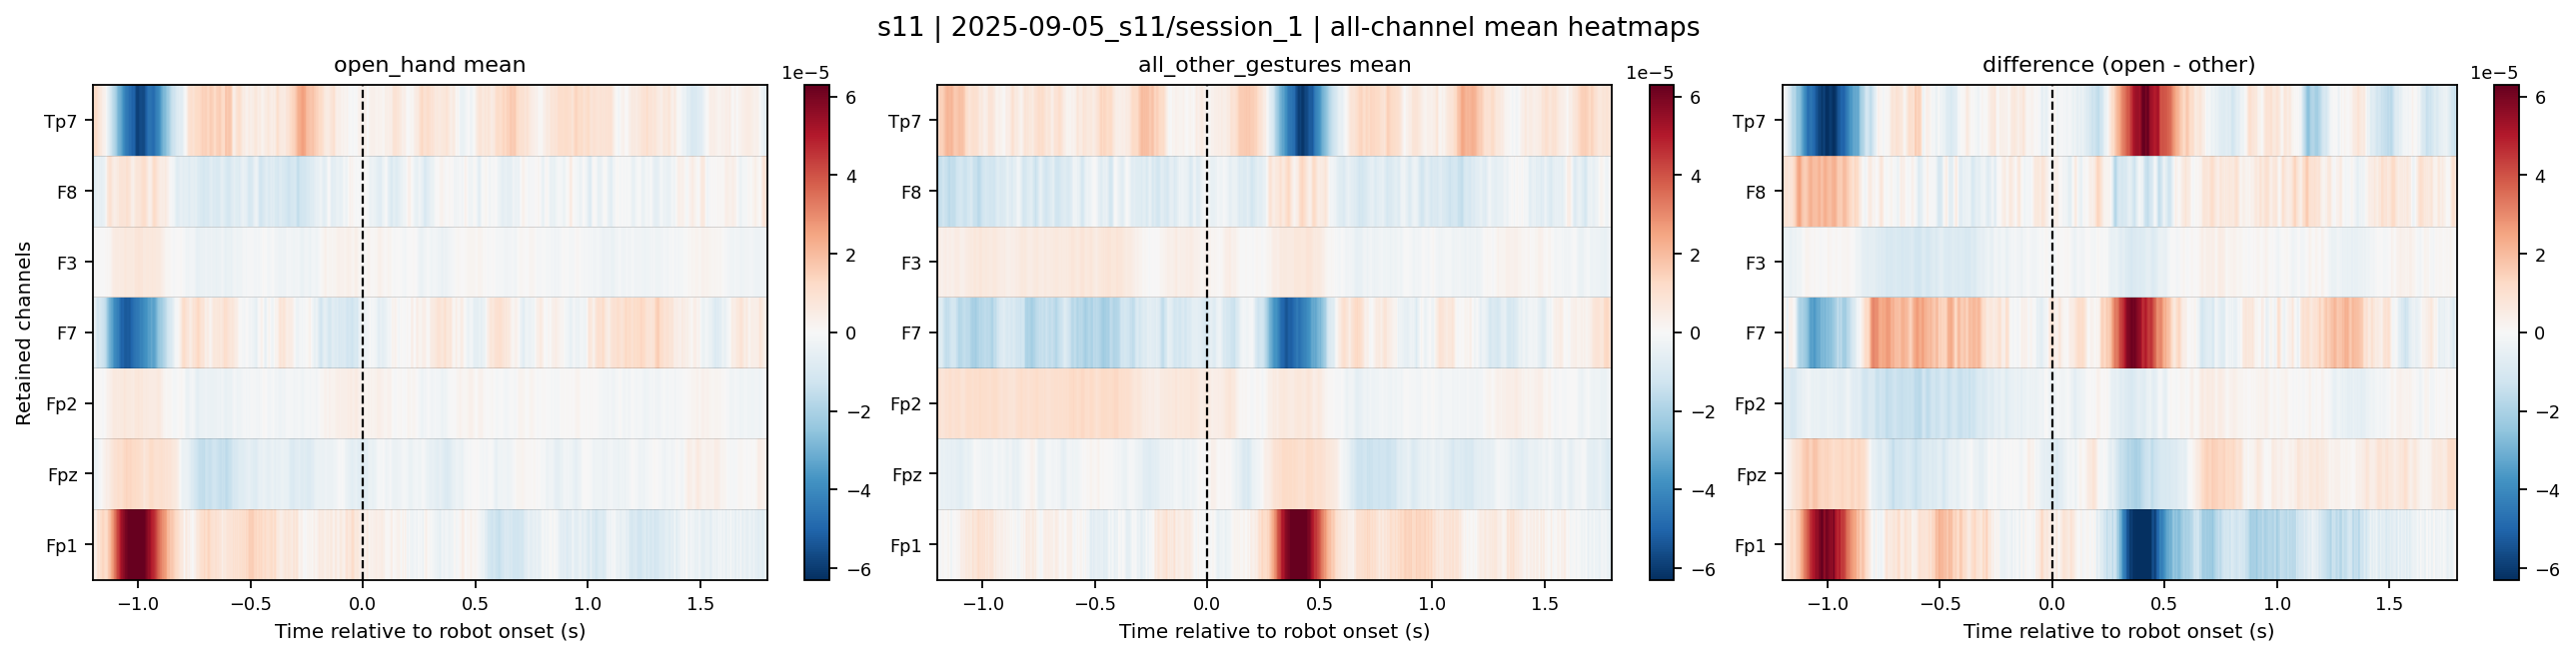

In [55]:

for obj in session_objects:
    session_name = obj['session_name']
    safe = sanitize_session_name(session_name)
    epochs = obj['epochs']

    plot_all_channel_mean_heatmaps(
        epochs, PATIENT_ID, session_name,
        DIRS['raw_session'] / f'{safe}__all_channel_mean_heatmaps'
    )
    plot_channel_overlay_grid(
        epochs, PATIENT_ID, session_name,
        DIRS['raw_session'] / f'{safe}__channel_overlay_grid'
    )

print('Saved session-level raw / ERP visualizations to:')
print(DIRS['raw_session'])

if SHOW_INLINE_PREVIEW and session_objects:
    preview_session = session_objects[0]['epochs']
    plot_all_channel_mean_heatmaps(preview_session, PATIENT_ID, session_objects[0]['session_name'], OUTPUT_ROOT / '_tmp_preview_heatmaps')
    from IPython.display import Image
    display(Image(filename=str((OUTPUT_ROOT / '_tmp_preview_heatmaps').with_suffix('.png'))))


## 5. Session-level TFR visualizations

In [56]:

for obj in session_objects:
    session_name = obj['session_name']
    safe = sanitize_session_name(session_name)
    epochs = obj['epochs']

    tfr_open = compute_mean_tfr(epochs, 'open_hand')
    tfr_other = compute_mean_tfr(epochs, 'all_other_gestures')

    plot_tfr_channel_pages(
        tfr_open, tfr_other,
        PATIENT_ID, session_name,
        DIRS['tfr_session'],
        prefix=safe,
    )

print('Saved session-level TFR visualizations to:')
print(DIRS['tfr_session'])


Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Saved session-level TFR visualizations to:
/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/02_session_level_tfr


## 6. Patient-level aggregated visualizations across all selected sessions

In [57]:

plot_all_channel_mean_heatmaps(
    patient_epochs,
    PATIENT_ID,
    'ALL_SELECTED_SESSIONS',
    DIRS['raw_patient'] / f'{PATIENT_ID}__ALL_SELECTED_SESSIONS__all_channel_mean_heatmaps'
)
plot_channel_overlay_grid(
    patient_epochs,
    PATIENT_ID,
    'ALL_SELECTED_SESSIONS',
    DIRS['raw_patient'] / f'{PATIENT_ID}__ALL_SELECTED_SESSIONS__channel_overlay_grid'
)

patient_tfr_open = compute_mean_tfr(patient_epochs, 'open_hand')
patient_tfr_other = compute_mean_tfr(patient_epochs, 'all_other_gestures')
plot_tfr_channel_pages(
    patient_tfr_open,
    patient_tfr_other,
    PATIENT_ID,
    'ALL_SELECTED_SESSIONS',
    DIRS['tfr_patient'],
    prefix=f'{PATIENT_ID}__ALL_SELECTED_SESSIONS',
)

print('Saved patient-level aggregated visualizations to:')
print(DIRS['raw_patient'])
print(DIRS['tfr_patient'])


Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Saved patient-level aggregated visualizations to:
/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/03_patient_level_raw
/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/04_patient_level_tfr


## 7. Candidate panels for article selection

In [58]:

# This block copies / summarizes the most useful outputs into one place.
# You can later replace this logic with your own "best of" selection.

candidate_note = f"""
Suggested first-pass files to inspect for patient {PATIENT_ID}:

1) Session-level raw / ERP:
   - one file per session: *__all_channel_mean_heatmaps.png
   - one file per session: *__channel_overlay_grid.png

2) Session-level TFR:
   - one or more files per session: *__tfr_page_XX.png

3) Patient-level aggregate:
   - {PATIENT_ID}__ALL_SELECTED_SESSIONS__all_channel_mean_heatmaps.png
   - {PATIENT_ID}__ALL_SELECTED_SESSIONS__channel_overlay_grid.png
   - {PATIENT_ID}__ALL_SELECTED_SESSIONS__tfr_page_XX.png

Recommended workflow:
- First inspect 03_patient_level_raw and 04_patient_level_tfr.
- Then inspect 01_session_level_raw and 02_session_level_tfr to find cleaner sessions/channels.
- If a session is especially clear, use its images as cherry-pick candidates for the paper.
""".strip()
write_text_summary(DIRS['candidate_panels'] / f'{PATIENT_ID}__how_to_read_outputs.txt', candidate_note)
print(candidate_note)


Suggested first-pass files to inspect for patient s11:

1) Session-level raw / ERP:
   - one file per session: *__all_channel_mean_heatmaps.png
   - one file per session: *__channel_overlay_grid.png

2) Session-level TFR:
   - one or more files per session: *__tfr_page_XX.png

3) Patient-level aggregate:
   - s11__ALL_SELECTED_SESSIONS__all_channel_mean_heatmaps.png
   - s11__ALL_SELECTED_SESSIONS__channel_overlay_grid.png
   - s11__ALL_SELECTED_SESSIONS__tfr_page_XX.png

Recommended workflow:
- First inspect 03_patient_level_raw and 04_patient_level_tfr.
- Then inspect 01_session_level_raw and 02_session_level_tfr to find cleaner sessions/channels.
- If a session is especially clear, use its images as cherry-pick candidates for the paper.


## 8. Quick inline preview of saved files

Preview files:
 - /trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/03_patient_level_raw/s11__ALL_SELECTED_SESSIONS__all_channel_mean_heatmaps.png


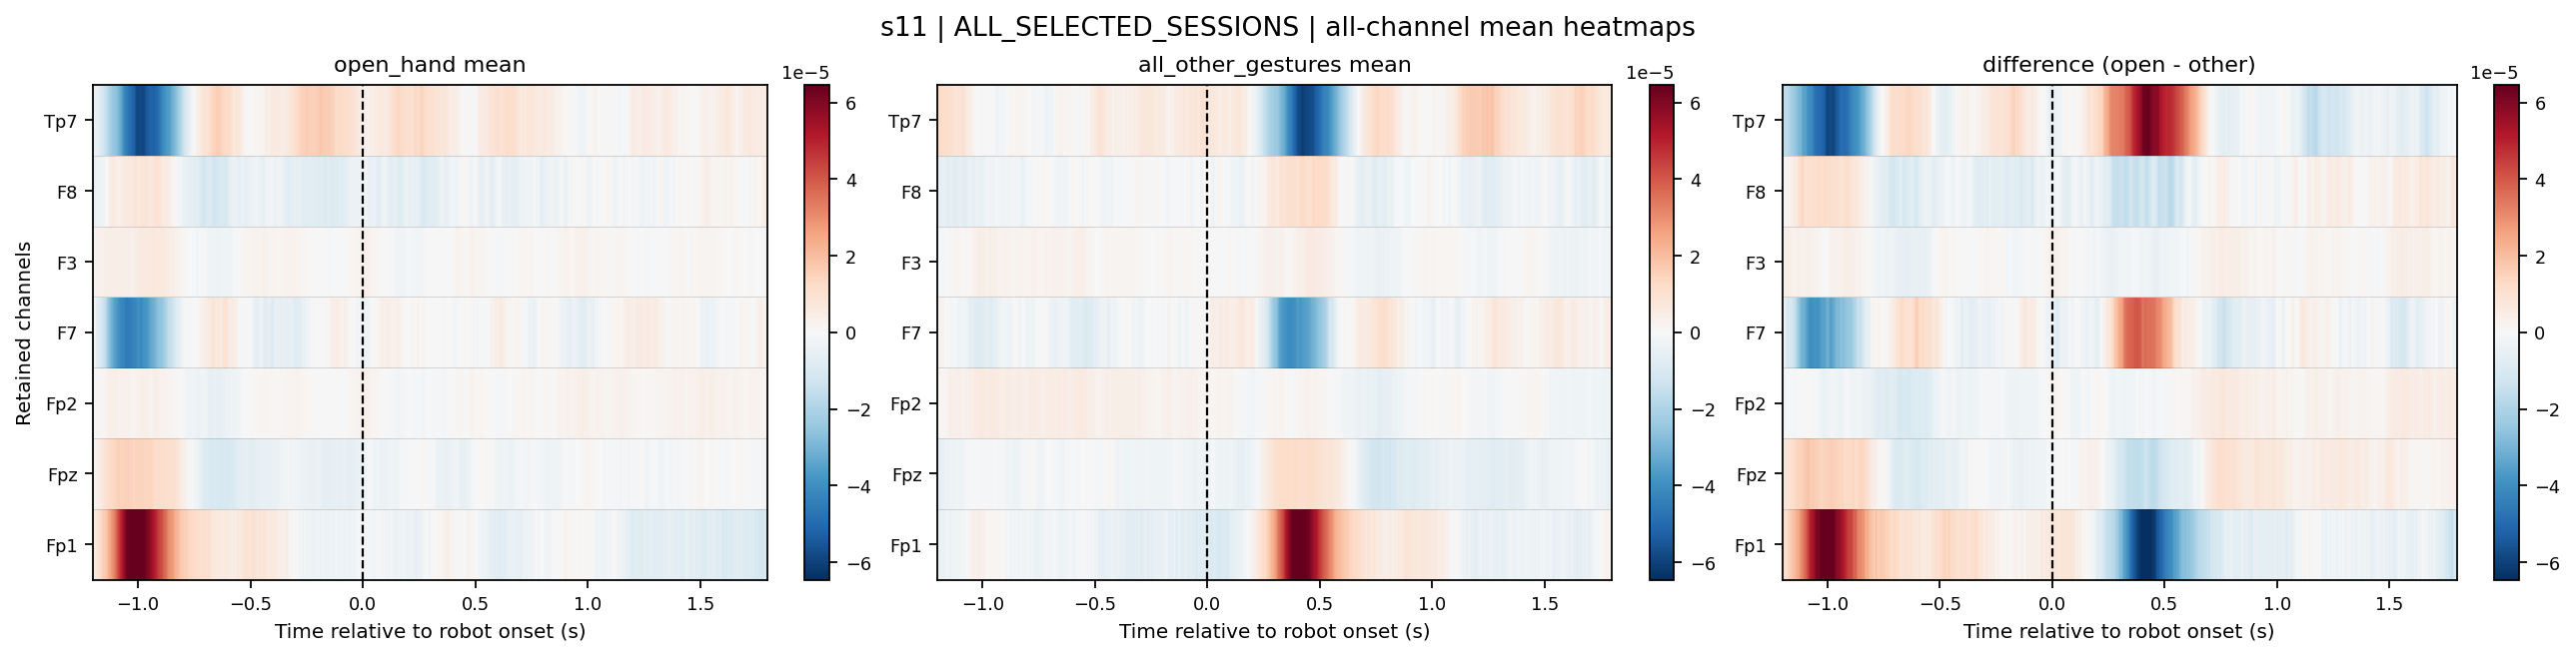

 - /trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/03_patient_level_raw/s11__ALL_SELECTED_SESSIONS__channel_overlay_grid.png


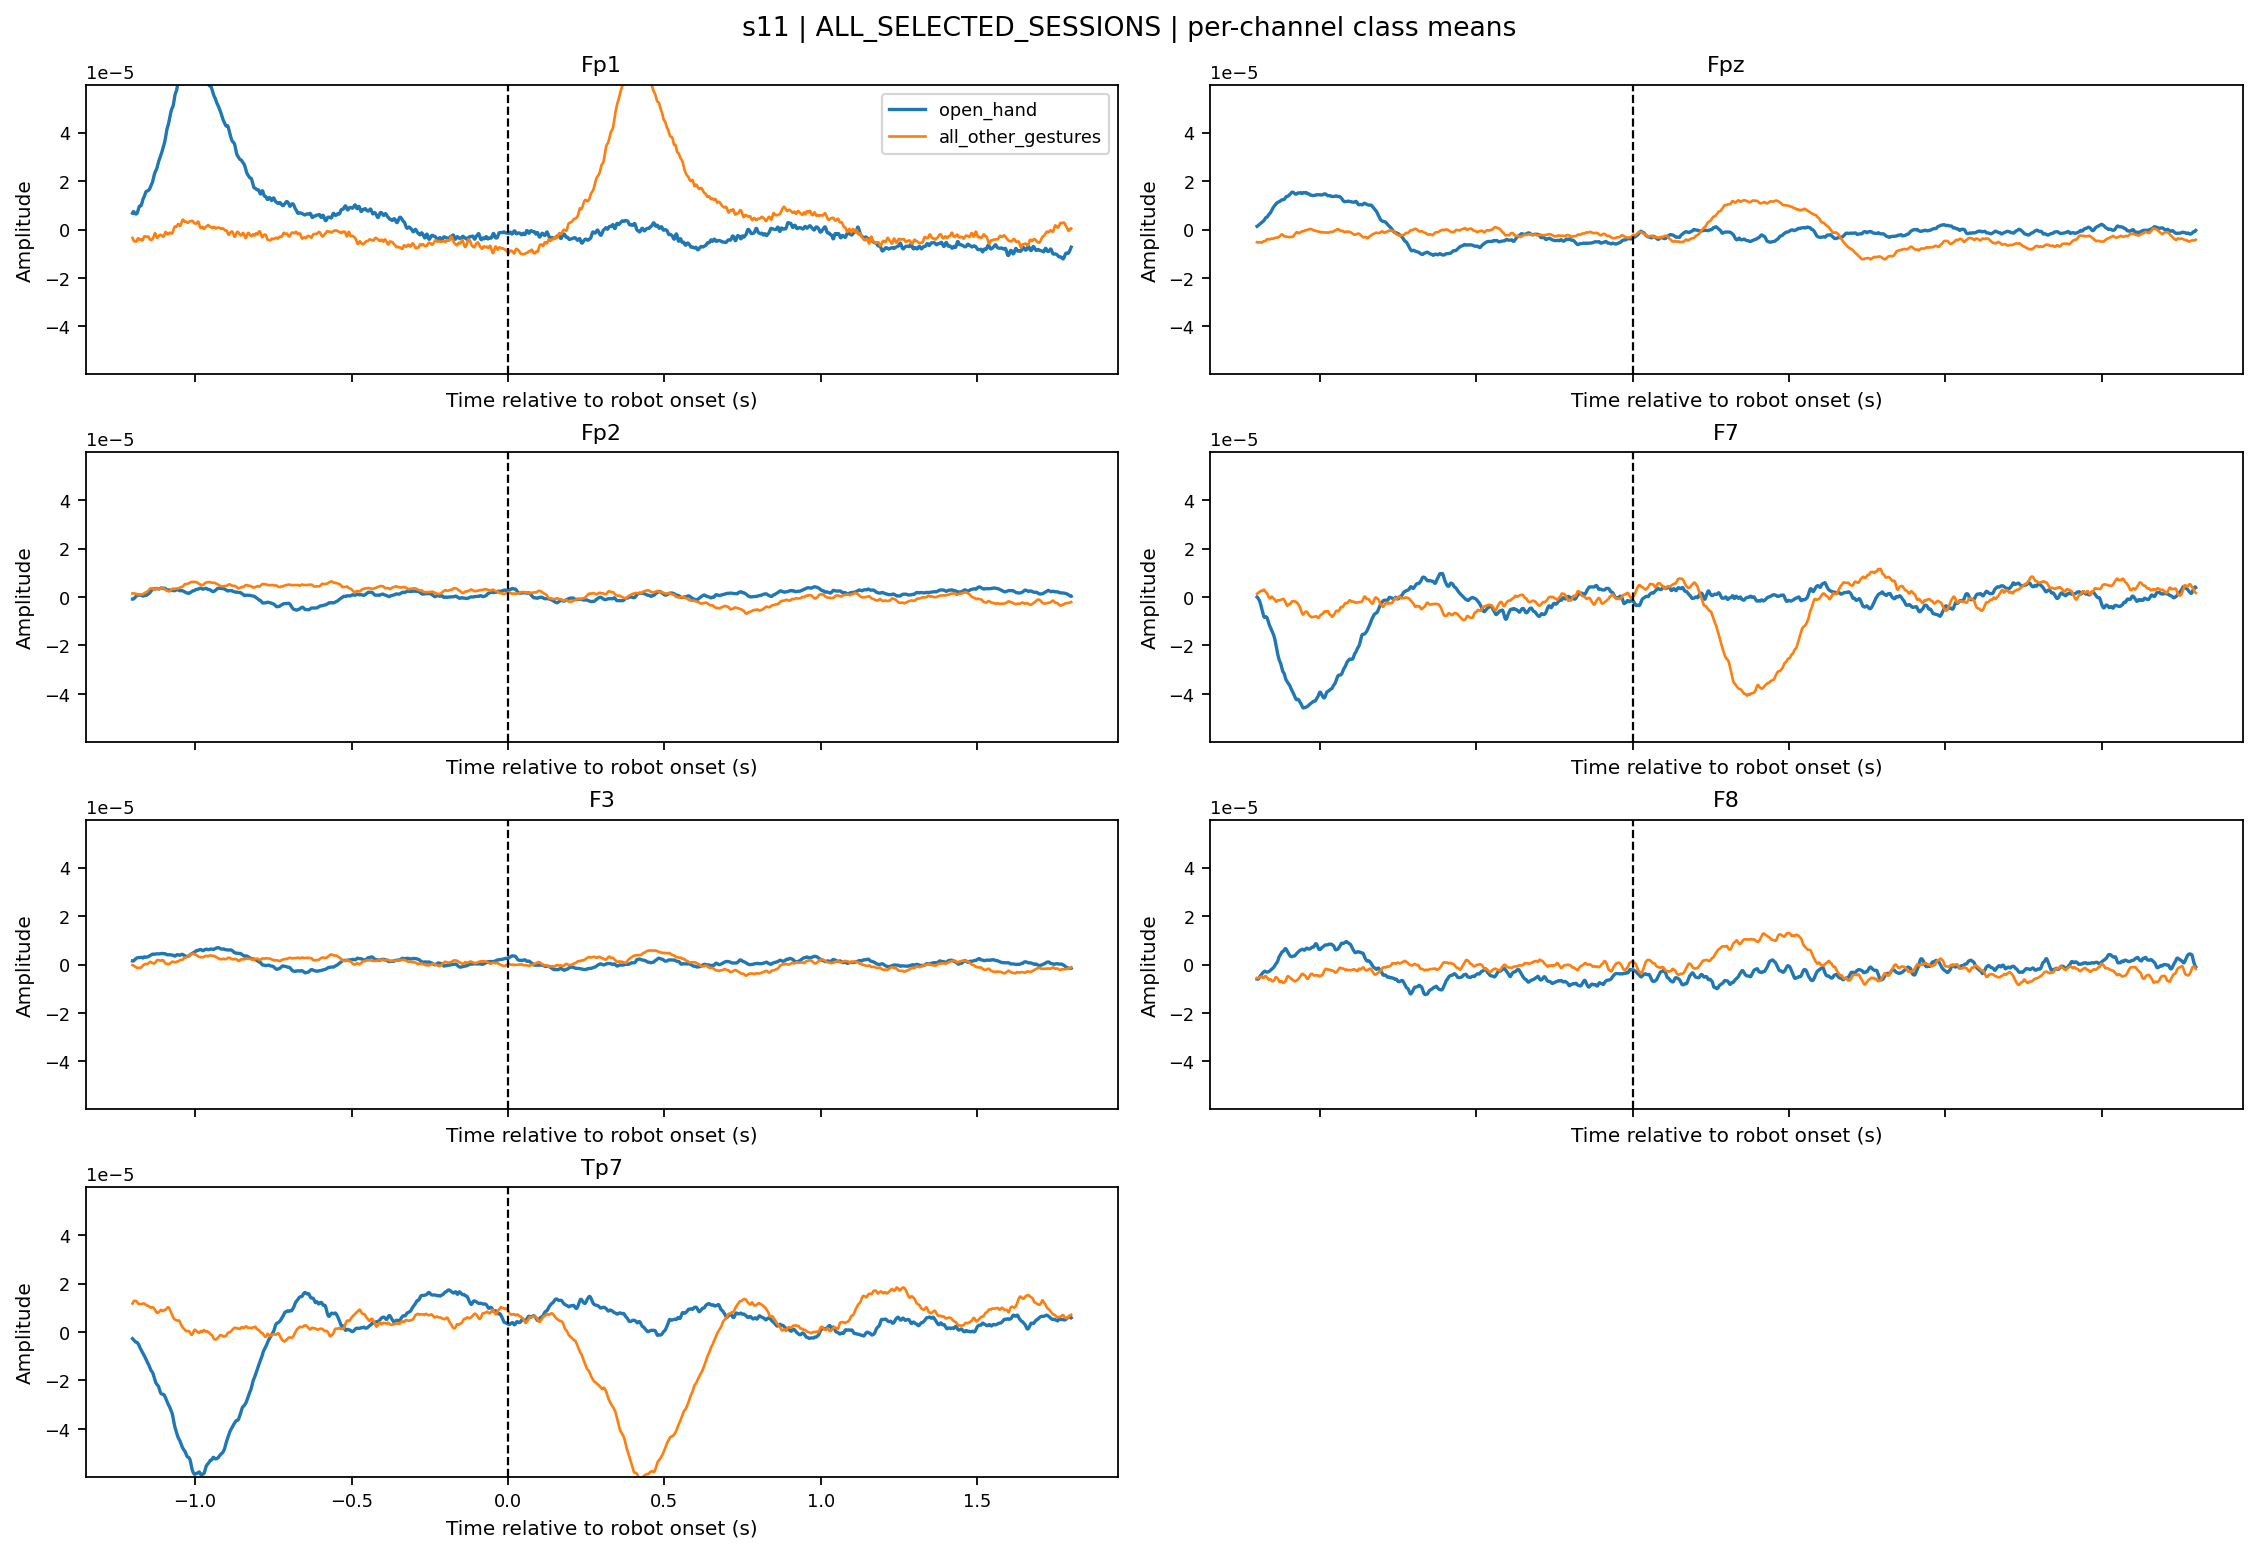

 - /trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/04_patient_level_tfr/s11__ALL_SELECTED_SESSIONS__tfr_page_01.png


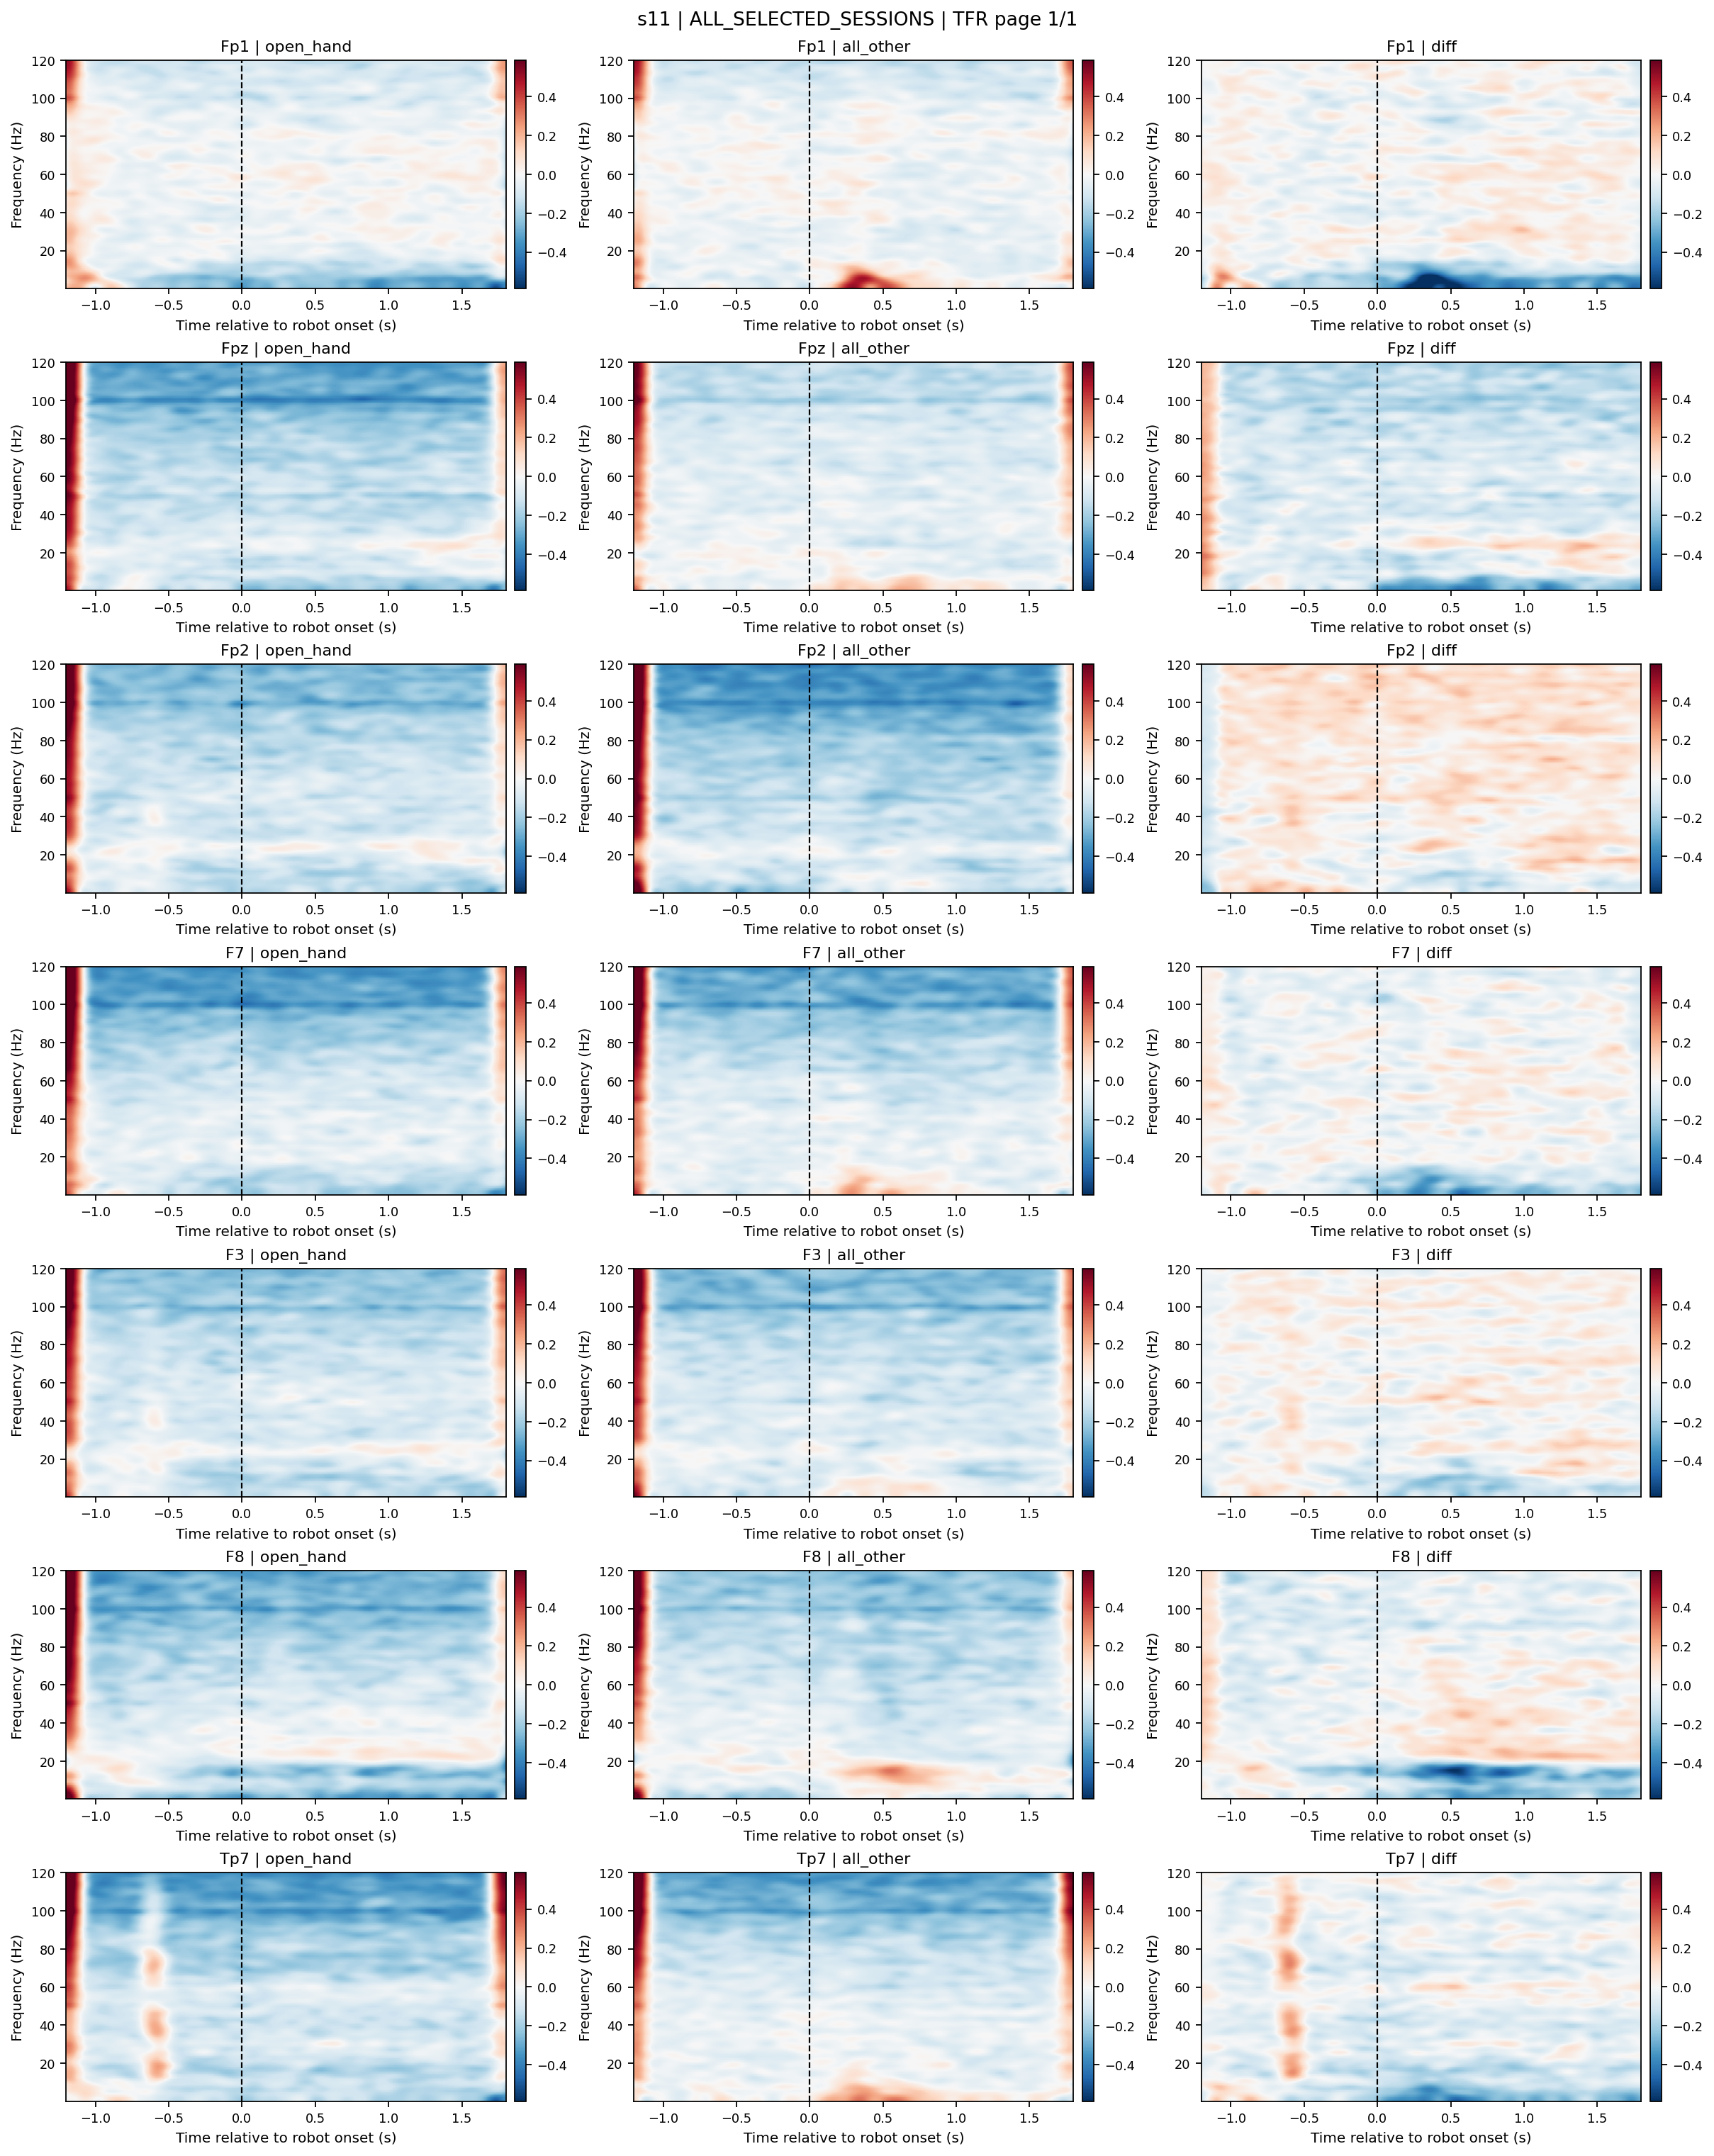

In [59]:

from IPython.display import Image, display

preview_files = sorted(DIRS['raw_patient'].glob('*.png'))[:2] + sorted(DIRS['tfr_patient'].glob('*.png'))[:2]
print('Preview files:')
for p in preview_files:
    print(' -', p)
    display(Image(filename=str(p)))



## 9. Что смотреть в каких подпапках

### `00_metadata`
- CSV-таблицы и краткая справка по запуску.
- Удобно для проверки, какие сессии попали в анализ и сколько там эпох.

### `01_session_level_raw`
- По каждой сессии: class means по всем retained channels.
- Хорошо подходит для поиска **самых чистых сессий**.

### `02_session_level_tfr`
- По каждой сессии: TFR `open_hand`, `all_other_gestures`, `difference`.
- Хорошо подходит для поиска **самых выразительных time-frequency картинок**.

### `03_patient_level_raw`
- Агрегация по всем выбранным сессиям пациента.
- Это первая папка, куда стоит смотреть, если нужен **общий образ пациента**.

### `04_patient_level_tfr`
- TFR-агрегация по пациенту.
- Хорошо подходит для общего выбора каналов / частотно-временных паттернов.

### `05_candidate_panels`
- Пока содержит текстовую памятку.
- Сюда можно руками копировать понравившиеся картинки для статьи.


## 10. Patient-level final figures

Эта ячейка запускается после создания `patient_epochs`.


In [60]:

# ============================================================
# 10. PATIENT-LEVEL FIGURES
# Run this after the cell that creates `patient_epochs`.
# ============================================================

PATIENT_LEVEL_DIR = ensure_dir(OUTPUT_ROOT / "06_patient_level_final")
PATIENT_LEVEL_RAW_DIR = ensure_dir(PATIENT_LEVEL_DIR / "01_raw")
PATIENT_LEVEL_TFR_DIR = ensure_dir(PATIENT_LEVEL_DIR / "02_tfr")

patient_label = "ALL_SELECTED_SESSIONS"

# Raw / ERP patient-level figures
plot_all_channel_mean_heatmaps(
    patient_epochs,
    PATIENT_ID,
    patient_label,
    PATIENT_LEVEL_RAW_DIR / f"{PATIENT_ID}__patient_level__all_channel_mean_heatmaps",
)

plot_channel_overlay_grid(
    patient_epochs,
    PATIENT_ID,
    patient_label,
    PATIENT_LEVEL_RAW_DIR / f"{PATIENT_ID}__patient_level__channel_overlay_grid",
)

# TFR patient-level figures
patient_tfr_open = compute_mean_tfr(patient_epochs, "open_hand")
patient_tfr_other = compute_mean_tfr(patient_epochs, "all_other_gestures")

plot_tfr_channel_pages(
    patient_tfr_open,
    patient_tfr_other,
    PATIENT_ID,
    patient_label,
    PATIENT_LEVEL_TFR_DIR,
    prefix=f"{PATIENT_ID}__patient_level",
)

print("Patient-level figures saved to:")
print(" ", PATIENT_LEVEL_RAW_DIR)
print(" ", PATIENT_LEVEL_TFR_DIR)


Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Patient-level figures saved to:
  /trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/06_patient_level_final/01_raw
  /trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/06_patient_level_final/02_tfr


## 11. Final candidate-panel collector

Эта ячейка запускается самой последней, когда все нужные изображения уже построены.


In [61]:

# ============================================================
# 11. COLLECT CANDIDATE PANELS
# Run this as the LAST cell, after all desired figures exist.
# It scans OUTPUT_ROOT recursively and does not depend on DIRS keys.
# ============================================================

import shutil

CANDIDATE_DIR = ensure_dir(OUTPUT_ROOT / "07_candidate_panels_final")

# Clean only files previously copied by this cell.
for old_file in CANDIDATE_DIR.iterdir():
    if old_file.is_file():
        old_file.unlink()

def collect_files(patterns, label, max_files=None):
    found = []
    seen = set()

    for pattern in patterns:
        for path in sorted(OUTPUT_ROOT.rglob(pattern)):
            if CANDIDATE_DIR in path.parents:
                continue
            resolved = path.resolve()
            if resolved in seen:
                continue
            seen.add(resolved)
            found.append(path)

    if max_files is not None:
        found = found[:max_files]

    copied = []
    for idx, source in enumerate(found, start=1):
        destination = CANDIDATE_DIR / (
            f"{label}__{idx:02d}__{source.parent.name}__{source.name}"
        )
        shutil.copy2(source, destination)
        copied.append(destination)

    return copied

candidate_files = []

candidate_files += collect_files(
    ["*all_channel_mean_heatmaps.png"],
    "01_raw_heatmap",
)

candidate_files += collect_files(
    ["*channel_overlay_grid.png"],
    "02_channel_overlays",
)

candidate_files += collect_files(
    ["*tfr_page_*.png"],
    "03_tfr",
)

candidate_files += collect_files(
    ["*aggregate_discriminability*.png"],
    "04_aggregate_discriminability",
)

candidate_files += collect_files(
    ["*discriminability_page_*.png"],
    "05_channel_discriminability",
)

candidate_files += collect_files(
    ["*gesture*erp*.png", "*open_minus_each*.png"],
    "06_per_gesture",
)

# Numerical summaries, if they already exist.
summary_files = []
for pattern in ("*window_summary.csv", "*decoder_window_summary.csv"):
    summary_files.extend(sorted(OUTPUT_ROOT.rglob(pattern)))

for idx, source in enumerate(summary_files, start=1):
    if CANDIDATE_DIR in source.parents:
        continue
    destination = CANDIDATE_DIR / (
        f"07_summary__{idx:02d}__{source.parent.name}__{source.name}"
    )
    shutil.copy2(source, destination)
    candidate_files.append(destination)

candidate_manifest = pd.DataFrame({
    "order": range(1, len(candidate_files) + 1),
    "filename": [p.name for p in candidate_files],
    "source_or_copy_path": [str(p) for p in candidate_files],
})

candidate_manifest.to_csv(
    CANDIDATE_DIR / f"{PATIENT_ID}__candidate_manifest.csv",
    index=False,
)

readme = f"""
Patient: {PATIENT_ID}

This folder is collected automatically from all PNG and CSV outputs
already present under:

{OUTPUT_ROOT}

Recommended order:
1. 01_raw_heatmap
2. 02_channel_overlays
3. 03_tfr
4. 04_aggregate_discriminability
5. 05_channel_discriminability
6. 06_per_gesture
7. 07_summary

Important:
- This cell does not recompute figures.
- It only copies already generated outputs into one folder.
""".strip()

(CANDIDATE_DIR / f"{PATIENT_ID}__README.txt").write_text(
    readme,
    encoding="utf-8",
)

print(f"Collected {len(candidate_files)} files into:")
print(CANDIDATE_DIR)
display(candidate_manifest)


Collected 23 files into:
/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/07_candidate_panels_final


,order,filename,source_or_copy_path
0,1,01_raw_heatmap__01__01_session_level_raw__2025...,/trinity/home/t.samsonov/notebooks/Pirogov/Pre...
1,2,01_raw_heatmap__02__01_session_level_raw__2025...,/trinity/home/t.samsonov/notebooks/Pirogov/Pre...
2,3,01_raw_heatmap__03__03_patient_level_raw__s11_...,/trinity/home/t.samsonov/notebooks/Pirogov/Pre...
3,4,01_raw_heatmap__04__01_raw__s11__patient_level...,/trinity/home/t.samsonov/notebooks/Pirogov/Pre...
4,5,02_channel_overlays__01__01_session_level_raw_...,/trinity/home/t.samsonov/notebooks/Pirogov/Pre...
5,6,02_channel_overlays__02__01_session_level_raw_...,/trinity/home/t.samsonov/notebooks/Pirogov/Pre...
6,7,02_channel_overlays__03__03_patient_level_raw_...,/trinity/home/t.samsonov/notebooks/Pirogov/Pre...
7,8,02_channel_overlays__04__01_raw__s11__patient_...,/trinity/home/t.samsonov/notebooks/Pirogov/Pre...
8,9,03_tfr__01__02_session_level_tfr__2025-09-05_s...,/trinity/home/t.samsonov/notebooks/Pirogov/Pre...
9,10,03_tfr__02__02_session_level_tfr__2025-09-05_s...,/trinity/home/t.samsonov/notebooks/Pirogov/Pre...
